# Analyse Name Embeddings

This analysis notebook specifically deals with embeddings generated from context graphs located in the NAME directory i.e. expression data averaged across experimental context AND perturbagen name.

# Imports

In [1]:
from adjustText import adjust_text
from itertools import combinations
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm as tqdm
import seaborn as sns

import umap.umap_ as umap

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Directories

In [2]:
# Define current directory
cwd = Path.cwd()
# Define DATA directory
DATA = cwd.parents[1]/'data'/'canada'

# Define INPUT directory
INPUT = DATA / 'input'

# Define OUTPUT directory
OUTPUT = DATA / 'output'

# Define CONTEXT directory
CONTEXT = OUTPUT / 'context_graphs'

# Define RNASEQ directory
RNASEQ = CONTEXT / 'rnaseq'

# Define CID directory
CID = CONTEXT / 'cid'

# Define MEAN directory
MEAN = CONTEXT / 'mean'

# Functions

## General

In [3]:
def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def list_to_file(path, data):
      '''
      Saves a list or set to a .txt file with no header.
      '''

      with open(path, 'w') as f:
            for item in sorted(data):
                  f.write(f'{item}\n')

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

# Analysis

## uMAP

In [4]:
# Load perturbagen info
df_perturbagen_info = pd.read_csv(OUTPUT / 'df_perturbagen_info.csv')
# Show data
df_perturbagen_info.head()

,perturbagen_id,perturbagen_name
0,DMSO,DMSO
1,BRD-A03772856,BRD-A03772856
2,BRD-A19037878,trichostatin-a
3,BRD-A19500257,geldanamycin
4,BRD-A34037822,KUC107191N


In [5]:
# Load embeddings
list_emb = pickle_load(OUTPUT / 'list_emb.pkl')
# Load list_pyg
list_pyg = pickle_load(OUTPUT / 'list_pyg.pkl')

# Stack embeddings
emb_stack = np.stack(list_emb, axis = 0)
# Generate mean consensus embedding
consensus_emb = emb_stack.mean(axis = 0)

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\roman\AppData\Lo

In [6]:
# Run uMAP embeddings
umap_embed = umap.UMAP(metric = 'cosine').fit_transform(consensus_emb)
# Extract graph data
graph_ids = [graph.name for graph in list_pyg]
graph_timepoints = [graph.timepoint for graph in list_pyg]

# Convert to dataframe
df_umap = pd.DataFrame(umap_embed, columns = ['x', 'y'])
df_umap['perturbagen_id'] = graph_ids
df_umap['timepoint'] = graph_timepoints

# Merge
df_umap = pd.merge(df_umap, df_perturbagen_info, how = 'left', on = 'perturbagen_id')
df_umap['perturbagen_name'] = df_umap['perturbagen_name'].fillna(df_umap['perturbagen_id'])

# Save data
df_umap.to_csv(OUTPUT / 'df_umap.csv', index = False)
# Show data
df_umap.head()

,x,y,perturbagen_id,timepoint,perturbagen_name
0,0.458387,3.627176,Halo,6H,Halo
1,-2.227221,4.618439,Nita,6H,Nita
2,-2.171800,4.612518,Paro,6H,Paro
3,10.622456,6.234480,1616-dimethylprostaglandin-e2,6H,1616-dimethylprostaglandin-e2
4,13.582806,5.173715,5-methoxytryptamine,6H,5-methoxytryptamine


## Plot uMAP

In [7]:
# Load statin list
list_statins = file_to_list(OUTPUT / 'list_statin_ids.txt')
# Load opioid list
list_opioids = file_to_list(OUTPUT / 'list_opioid_ids.txt')
# Load profen list
list_profens = file_to_list(OUTPUT / 'list_profen_ids.txt')
# Load hdac list
list_hdac = file_to_list(OUTPUT / 'list_hdac_ids.txt')

In [8]:
# Convert IDs to names
list_statin_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_statins)].values.tolist()
list_opioid_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_opioids)].values.tolist()
list_profen_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_profens)].values.tolist()
list_hdac_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_hdac)].values.tolist()

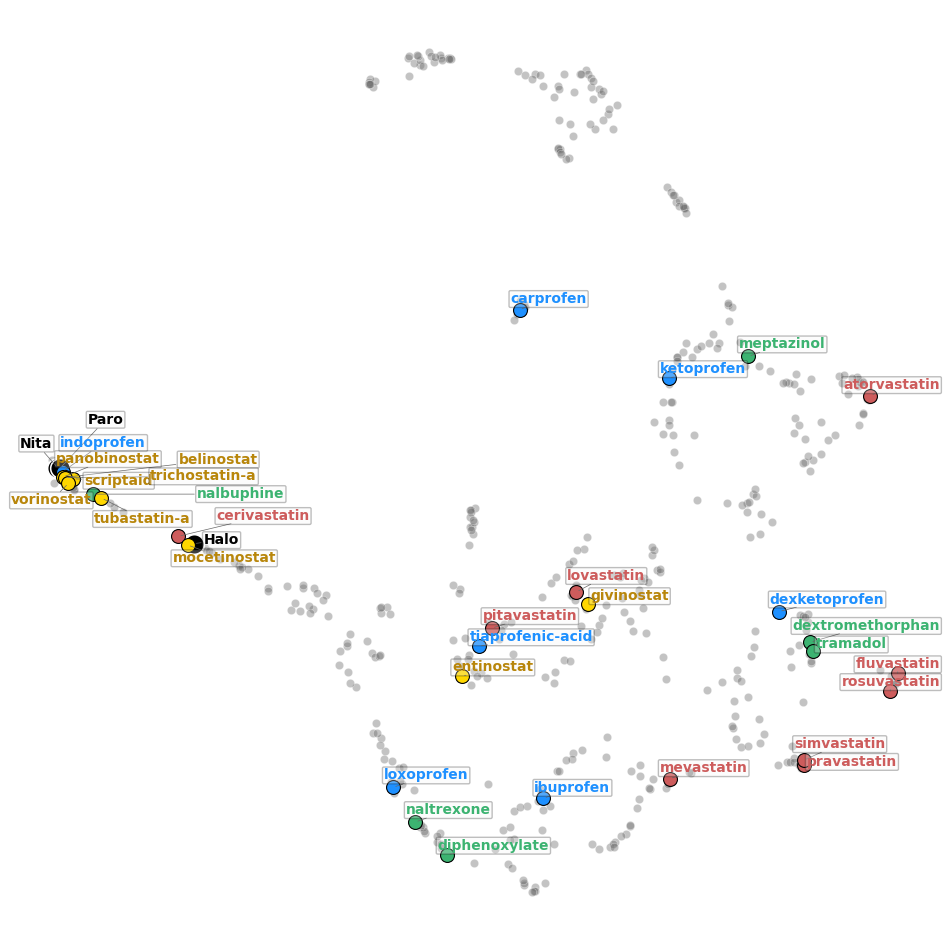

In [37]:
# Define treatment list
list_treat = ['Halo', 'Nita', 'Paro'] 

# Plot
plt.figure(figsize = (12,12))
sns.scatterplot(df_umap, x = 'x', y = 'y', color = 'dimgrey', alpha = 0.4)
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_treat)], x = 'x', y = 'y', color = 'black', s = 200)
#sns.scatterplot(df_umap[df_umap['perturbagen_name'].str.contains('statin')], x = 'x', y = 'y', color = 'indianred', s = 100, edgecolor = 'black')
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_statin_names)], x = 'x', y = 'y', color = 'indianred', s = 100, edgecolor = 'black')
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_opioid_names)], x = 'x', y = 'y', color = 'mediumseagreen', s = 100, edgecolor = 'black')
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_profen_names)], x = 'x', y = 'y', color = 'dodgerblue', s = 100, edgecolor = 'black')
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_hdac_names)], x = 'x', y = 'y', color = 'gold', s = 100, edgecolor = 'black')

list_text = []
seen_points = set()   # prevent exact duplicates only

for idx, row in df_umap.iterrows():
    drug = row['perturbagen_name']
    x, y = row['x'], row['y']

    # Skip points that are not in any category
    if (
        drug not in list_treat and
        drug not in list_statin_names and
        drug not in list_opioid_names and
        drug not in list_profen_names and
        drug not in list_hdac_names
    ):
        continue

    # Prevent duplicate label if exact same coordinate/name repeats
    key = (drug, x, y)
    if key in seen_points:
        continue
    seen_points.add(key)

    # Color logic
    if drug in list_treat:
        label_color = 'black'
    elif drug in list_statin_names:
        label_color = 'indianred'
    elif drug in list_opioid_names:
        label_color = 'mediumseagreen'
    elif drug in list_profen_names:
        label_color = 'dodgerblue'
    elif drug in list_hdac_names:
        label_color = 'darkgoldenrod'
    else:
        label_color = 'black'

    # Label style
    label_style = {
        'fontsize': 10,
        'alpha': 1,
        'weight': 'bold',
        'color': label_color,
        'ha': 'center',
        'va': 'bottom',
        'bbox': {
            'facecolor': 'whitesmoke',
            'alpha': 0.25,
            'edgecolor': 'black',
            'boxstyle': 'round, pad=0.1'
        }
    }

    list_text.append(
        plt.text(x, y, drug, **label_style)
    )

# Adjust text positions
adjust_text(list_text, arrowprops=dict(arrowstyle='-', color='dimgrey', lw=0.5));

# Remove axes
plt.axis('off');

## Neighbour Composition

Here, the composition of the n closest neighbours from uMAP dimensionality reduction for each treatment is calculated. This is to visualise proportion of 'HDAC/statin/opioid/profen/other' perturbagens close to their embeddings.

In [10]:
# Load statin list
list_statins = file_to_list(OUTPUT / 'list_statin_ids.txt')
# Load opioid list
list_opioids = file_to_list(OUTPUT / 'list_opioid_ids.txt')
# Load profen list
list_profens = file_to_list(OUTPUT / 'list_profen_ids.txt')
# Load hdac list
list_hdac = file_to_list(OUTPUT / 'list_hdac_ids.txt')

# Convert IDs to names
list_statin_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_statins)].values.tolist()
list_opioid_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_opioids)].values.tolist()
list_profen_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_profens)].values.tolist()
list_hdac_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_hdac)].values.tolist()

# Load umap coordinates
df_umap = pd.read_csv(OUTPUT / 'df_umap.csv')
# Show data
df_umap.head()

,x,y,perturbagen_id,timepoint,perturbagen_name
0,0.458387,3.627176,Halo,6H,Halo
1,-2.227221,4.618439,Nita,6H,Nita
2,-2.171800,4.612518,Paro,6H,Paro
3,10.622456,6.234480,1616-dimethylprostaglandin-e2,6H,1616-dimethylprostaglandin-e2
4,13.582806,5.173715,5-methoxytryptamine,6H,5-methoxytryptamine


In [11]:
# Define list_treatment
list_treatment = ['Halo', 'Nita', 'Paro']

In [34]:
# Copy data
df_nn = df_umap.copy()
# Generate 'type' column
df_nn['type'] = 'other'
# Iterate over lists and apply labels
for type_list, label in zip([list_treatment, list_statin_names, list_opioid_names, list_profen_names, list_hdac_names],
                            ['treatment', 'statin', 'opioid', 'profen', 'hdac']):
    
    df_nn.loc[df_nn['perturbagen_id'].isin(type_list), 'type'] = label

# Show data
df_nn.head()

,x,y,perturbagen_id,timepoint,perturbagen_name,type
0,0.458387,3.627176,Halo,6H,Halo,treatment
1,-2.227221,4.618439,Nita,6H,Nita,treatment
2,-2.171800,4.612518,Paro,6H,Paro,treatment
3,10.622456,6.234480,1616-dimethylprostaglandin-e2,6H,1616-dimethylprostaglandin-e2,other
4,13.582806,5.173715,5-methoxytryptamine,6H,5-methoxytryptamine,other


In [25]:
# Define number of neighbours
NUM_NEIGHBOURS = 10

# Initialise dataframe
df_plot1 = pd.DataFrame()
df_plot2 = pd.DataFrame()

# Iterate over treatments
for treatment in list_treatment:

    # Get relevant data
    df = df_nn[['perturbagen_id', 'x', 'y']]

    # Set index
    df.set_index('perturbagen_id', inplace = True)

    # Get coordinate data
    coords = df.values
    
    # Initialise nearest neighbour model
    nn = NearestNeighbors(n_neighbors = NUM_NEIGHBOURS + 1)

    # Fit model
    nn.fit(coords)

    # Get index of treatment
    treatment_index = df.index.get_loc(treatment)

    # Get distances and indices of nearest neighbours
    distances, indices = nn.kneighbors([coords[treatment_index]])
    
    # Remove self distance/index
    distances = distances[0][1:]
    indices = indices[0][1:]

    # Map indices to perturbagen IDs
    ids = df.index[indices]

    # Convert to dataframe
    df_treatment = pd.DataFrame({
        'perturbagen_id' : ids,
        'distance' : distances
    })

    # Merge w/ drug type
    df_treatment = pd.merge(df_treatment, df_nn[['perturbagen_id', 'perturbagen_name', 'type']], on = 'perturbagen_id', how = 'left')

    # Group by type
    df_group = df_treatment[['type', 'perturbagen_name']].groupby(by = 'type').count()    
    # Calculate percentage
    df_group[treatment] = df_group['perturbagen_name'] / NUM_NEIGHBOURS * 100
    # Transpose data
    df_pivot = df_group[[treatment]].T
    # Concatenate
    df_plot1 = pd.concat([df_plot1, df_pivot])

    # Get type count
    df_type = df_group.copy()
    # Rename column
    df_type.rename(columns = {treatment : 'percent_neighbour', 'perturbagen_name' : 'count'}, inplace = True)
    # Reset index
    df_type.reset_index(inplace = True)
    # Add column
    df_type['treatment'] = treatment
    # Concatenate
    df_plot2 = pd.concat([df_plot2, df_type[['type', 'count', 'treatment']]])

# Format
df_plot1.fillna(0, inplace = True)
# Show data
df_plot1.head()

type,hdac,other,statin,profen,treatment
Halo,10.0,80.0,10.0,0.0,0.0
Nita,30.0,50.0,0.0,10.0,10.0
Paro,30.0,50.0,0.0,10.0,10.0


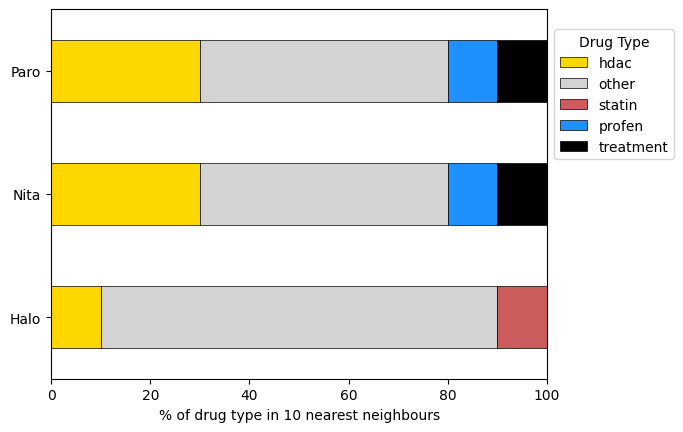

In [36]:
custom_colormap = {
    'hdac' : 'gold',
    'opioid' : 'mediumseagreen',
    'profen' : 'dodgerblue',
    'statin' : 'indianred',
    'other' : 'lightgrey',
    'treatment' : 'black'
}

plot = df_plot1.plot.barh(
    stacked = True, 
    color = custom_colormap, 
    xlim = (0,100), 
    edgecolor = 'black', 
    linewidth = 0.5,
    width = 0.5
)

plot.legend(
    title = 'Drug Type',
    labels=df_plot1.columns,      # or a custom list
    #labels = ['HDACi', 'Opioid', 'Other', 'Profen', 'Statin', 'Treatment'],
    loc = 'lower left',
    bbox_to_anchor=(1.0, 0.575)     # move legend outside the plot
)

plot.set_xlabel(f'% of drug type in {NUM_NEIGHBOURS} nearest neighbours');

In [27]:
df_plot2.head()

,type,count,treatment
0,hdac,1,Halo
1,other,8,Halo
2,statin,1,Halo
0,hdac,3,Nita
1,other,5,Nita


In [28]:
# Copy data
df_scatter = df_plot2.copy()
# Percent of neighbours
df_scatter['percent_n'] = df_scatter['count'] / NUM_NEIGHBOURS * 100
# Percent all
df_scatter['percent_all'] = float(0)
# Iterate over types
for drug_type in pd.unique(df_scatter['type']):
    
    # Get number of drugs of type
    NUM_TYPE = len(df_nn[df_nn['type'] == drug_type])

    print(drug_type, NUM_TYPE)

    # Get percent
    df_scatter.loc[df_scatter['type'] == drug_type, 'percent_all'] = df_scatter.loc[df_scatter['type'] == drug_type, 'count'] / NUM_TYPE * 100

df_scatter.head()

hdac 9
other 456
statin 9
profen 7
treatment 3


,type,count,treatment,percent_n,percent_all
0,hdac,1,Halo,10.0,11.111111
1,other,8,Halo,80.0,1.754386
2,statin,1,Halo,10.0,11.111111
0,hdac,3,Nita,30.0,33.333333
1,other,5,Nita,50.0,1.096491


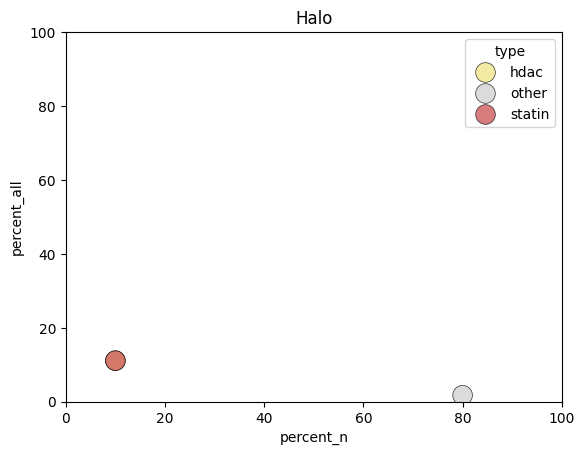

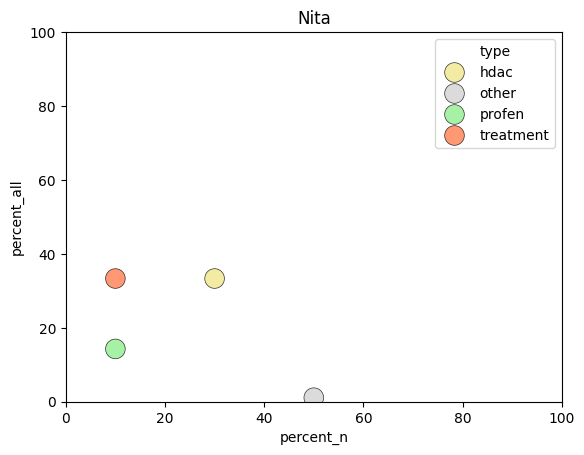

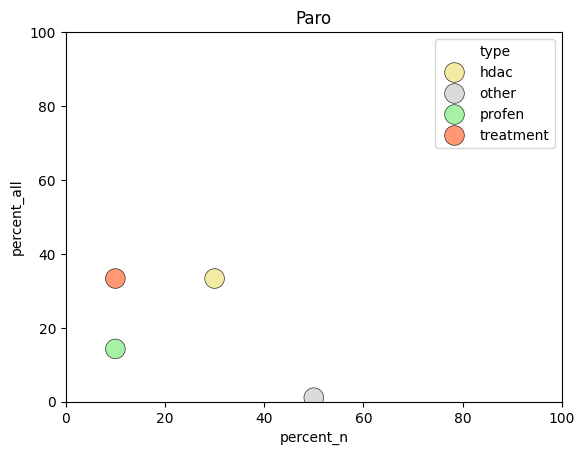

In [29]:
custom_colormap = {
    'hdac' : 'khaki',
    'opioid' : 'lightsteelblue',
    'profen' : 'lightgreen',
    'statin' : 'indianred',
    'other' : 'lightgrey',
    'treatment' : 'coral'
}

for treatment in list_treatment:
    # Slice
    df_slice = df_scatter[df_scatter['treatment'] == treatment]
    slice_plot = sns.scatterplot(df_slice, x = 'percent_n', y = 'percent_all', hue = 'type', s = 200, edgecolor = 'black', linewidth = 0.5, palette = custom_colormap, alpha = 0.8)
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.title(treatment)
    plt.show()

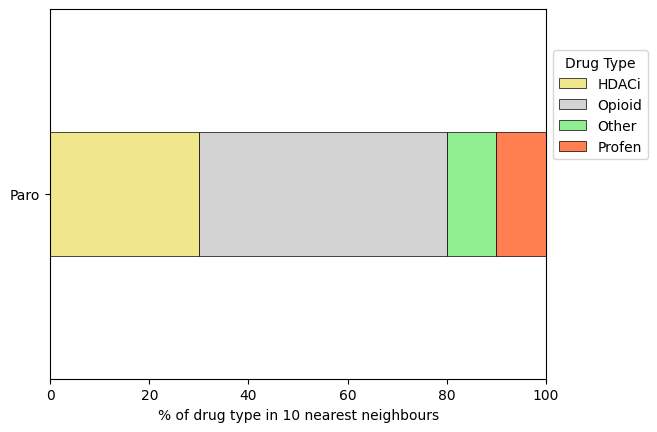

In [30]:
df_group = df_treatment[['type', 'perturbagen_name']].groupby(by = 'type').count()
df_group[treatment] = df_group['perturbagen_name'] / NUM_NEIGHBOURS * 100
df_pivot = df_group[[treatment]].T

custom_colormap = {
    'hdac' : 'khaki',
    'opioid' : 'lightsteelblue',
    'profen' : 'lightgreen',
    'statin' : 'indianred',
    'other' : 'lightgrey',
    'treatment' : 'coral'
}

plot = df_pivot.plot.barh(
    stacked = True, 
    color = custom_colormap, 
    xlim = (0,100), 
    edgecolor = 'black', 
    linewidth = 0.5,
    width = 0.25
)

plot.legend(
    title = 'Drug Type',
    #labels=df_pivot.columns,      # or a custom list
    labels = ['HDACi', 'Opioid', 'Other', 'Profen', 'Statin', 'Treatment'],
    loc = 'lower left',
    bbox_to_anchor=(1.0, 0.575)     # move legend outside the plot
)

plot.set_xlabel(f'% of drug type in {NUM_NEIGHBOURS} nearest neighbours');